# LightGBM Model — NYC 311 Service Requests

This notebook trains a **LightGBM classifier** to predict whether a 311 service request will be closed within 24 hours.

The preprocessing is not rewritten here because the group already created a common preprocessing file: `DS_processing.py`. This keeps the features consistent across all models in the project.

The target variable is:

- `Y = 1`: the request was closed within 24 hours
- `Y = 0`: the request was not closed within 24 hours

## Import the required libraries

This first section imports the libraries used for data manipulation, model training, evaluation and visualization.

LightGBM is used through its scikit-learn compatible class `LGBMClassifier`, which makes it easy to train the model and compute validation metrics.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from lightgbm import LGBMClassifier

## Define the project and data paths

`PROJECT_PATH` is the folder downloaded from GitHub. It is used to find the shared preprocessing file created by Matteo.

`DATA_PATH` is the folder containing the local CSV files. The CSV files should **not** be pushed to GitHub, so they are kept in a separate folder on the computer.

In [2]:
PROJECT_PATH = Path(r"C:\Users\romai\Downloads\Machine-Learning-Project-main")
DATA_PATH = Path(r"C:\Users\romai\Downloads\ML project data")

print("Project path:", PROJECT_PATH)
print("Data path:", DATA_PATH)

Project path: C:\Users\romai\Downloads\Machine-Learning-Project-main
Data path: C:\Users\romai\Downloads\ML project data


## Check that the required files exist

Before loading the data, this cell checks that the notebook can find:

- `DS_processing.py`, which contains the preprocessing functions
- `train.csv`, used for training and validation
- `test.csv`, used only for final predictions

If one of these lines returns `False`, the corresponding path needs to be corrected before continuing.

In [3]:
ds_processing_file = PROJECT_PATH / "Matteo" / "DS_processing.py"
train_file = DATA_PATH / "train.csv"
test_file = DATA_PATH / "test.csv"
column_description_file = DATA_PATH / "Column_Description.xlsx"

print("DS_processing.py exists:", ds_processing_file.exists())
print("train.csv exists:", train_file.exists())
print("test.csv exists:", test_file.exists())
print("Column description exists:", column_description_file.exists())

DS_processing.py exists: True
train.csv exists: True
test.csv exists: True
Column description exists: False


## Import the shared preprocessing functions

The two functions below were created for the project:

- `Process_train_DS`: prepares the training set and creates the target variable `Y`
- `Process_test_DS`: applies the same preprocessing to the test set, without creating `Y`

Using these functions ensures that this model uses the same features as the other notebooks.

In [4]:
sys.path.insert(0, str(PROJECT_PATH / "Matteo"))

from DS_processing import Process_train_DS, Process_test_DS

print("Preprocessing functions imported successfully.")

Preprocessing functions imported successfully.


## Load the raw data

The training file is used to train and validate the model.

The test file does not contain the closing date, so it cannot be used for validation. It is only used at the end to generate final predictions.

In [5]:
train_raw = pd.read_csv(train_file, index_col=0)
test_raw = pd.read_csv(test_file, index_col=0)

print("Raw training set shape:", train_raw.shape)
print("Raw test set shape:", test_raw.shape)

Raw training set shape: (110930, 40)
Raw test set shape: (27733, 39)


## Optional: inspect the column description file

The column description file is useful to understand the meaning of the variables. It is not necessary for training the model, but it can help when writing explanations in the final report.

This cell tries to load it only if it exists.

In [6]:
if column_description_file.exists():
    column_description = pd.read_excel(column_description_file)
    display(column_description.head(20))
else:
    print("Column description file not found. This is not a problem for training the model.")

Column description file not found. This is not a problem for training the model.


## Apply the shared preprocessing

The raw datasets are transformed using the common preprocessing functions.

For the training set, the preprocessing creates the target variable `Y`. For the test set, the same feature transformations are applied, but no target is created.

In [7]:
train = Process_train_DS(train_raw)
test = Process_test_DS(test_raw)

print("Processed training set shape:", train.shape)
print("Processed test set shape:", test.shape)

Dropped 0 rows because their 24-hour window hasn't expired yet.
Processed training set shape: (110930, 14)
Processed test set shape: (27733, 13)


## Inspect the processed training set

This step confirms which variables are available after preprocessing. The final training set should contain the target column `Y` and the engineered features created by `DS_processing.py`.

In [8]:
display(train.head())
print(train.dtypes)

,Agency,Incident Zip,Police Precinct,Borough,Open Data Channel Type,Problem_Grouped,Location_Grouped,Is_Landmark,Is_Taxi,Created_Hour,Created_DayOfWeek,Created_Month,Is_Weekend,Y
0,HPD,10011,Precinct 10,MANHATTAN,MOBILE,Housing & Buildings,Residential,0,0,8,1,4,0,1
1,HPD,10025,Precinct 24,MANHATTAN,ONLINE,Housing & Buildings,Residential,0,0,15,3,4,0,0
2,DSNY,11238,Precinct 88,BROOKLYN,PHONE,Sanitation & Garbage,Street/Sidewalk,1,0,12,6,4,1,0
3,DOB,10453,Precinct 46,BRONX,UNKNOWN,Other,Other/Mixed,0,0,12,4,4,0,0
4,HPD,10016,Precinct 13,MANHATTAN,PHONE,Housing & Buildings,Residential,0,0,9,3,4,0,0


Agency                    object
Incident Zip              object
Police Precinct           object
Borough                   object
Open Data Channel Type    object
Problem_Grouped           object
Location_Grouped          object
Is_Landmark                int32
Is_Taxi                    int32
Created_Hour               int32
Created_DayOfWeek          int32
Created_Month              int32
Is_Weekend                 int32
Y                          int32
dtype: object


## Check the target distribution

The target is not perfectly balanced. Because of this, the train-validation split uses `stratify=y` to keep the same proportion of classes in both sets.

In [9]:
target_distribution = train["Y"].value_counts(normalize=True).rename("proportion")
display(target_distribution.to_frame())

,proportion
Y,
1,0.613874
0,0.386126


## Define features and target

`X` contains the explanatory variables used by the model.

`y` contains the target variable to predict.

In [10]:
X = train.drop(columns=["Y"])
y = train["Y"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (110930, 13)
y shape: (110930,)


## Identify categorical variables

LightGBM can work directly with categorical variables when they are stored with the pandas `category` type.

This avoids using one-hot encoding and keeps the notebook simpler.

In [11]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['Agency', 'Incident Zip', 'Police Precinct', 'Borough', 'Open Data Channel Type', 'Problem_Grouped', 'Location_Grouped']


## Convert categorical variables

The categorical variables are converted in both the training and test sets.

The test set is also aligned with the training columns to make sure the final prediction step uses exactly the same variables.

In [12]:
for col in categorical_cols:
    X[col] = X[col].astype("category")
    test[col] = test[col].astype("category")

test = test[X.columns]

print("Categorical conversion completed.")

Categorical conversion completed.


## Create the train-validation split

The validation set is created from the training data because the official test set has no target variable.

The argument `stratify=y` preserves the original class proportions in both the training and validation sets.

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Y mean in training:", round(y_train.mean(), 4))
print("Y mean in validation:", round(y_val.mean(), 4))

Training set: (88744, 13)
Validation set: (22186, 13)
Y mean in training: 0.6139
Y mean in validation: 0.6139


## Define the LightGBM model

LightGBM is a gradient boosting model based on decision trees. It is well suited for tabular data and can handle non-linear relationships between variables.

The model below uses a moderate learning rate and several trees. The class weight is adjusted using `scale_pos_weight` to account for the difference between the two classes.

In [14]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("scale_pos_weight:", round(scale_pos_weight, 4))

scale_pos_weight: 0.629


## Train the model

The model is trained on the training split only. The validation set is kept separate and is used only to evaluate performance.

In [15]:
lgbm_model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)

print("LightGBM model trained successfully.")

LightGBM model trained successfully.


## Predict on the validation set

The model outputs both class predictions and probabilities.

The probabilities are useful for the ROC-AUC metric, while the predicted classes are used for accuracy, precision, recall and F1-score.

In [16]:
y_pred_val = lgbm_model.predict(X_val)
y_proba_val = lgbm_model.predict_proba(X_val)[:, 1]

print("Validation predictions completed.")

Validation predictions completed.


## Evaluate the model

This section reports the main classification metrics.

- Accuracy measures the overall proportion of correct predictions.
- Precision measures how many predicted positive cases are actually positive.
- Recall measures how many actual positive cases are detected.
- F1-score balances precision and recall.
- ROC-AUC evaluates the quality of the predicted probabilities.

In [17]:
metrics = {
    "Accuracy": accuracy_score(y_val, y_pred_val),
    "Precision": precision_score(y_val, y_pred_val),
    "Recall": recall_score(y_val, y_pred_val),
    "F1-score": f1_score(y_val, y_pred_val),
    "ROC-AUC": roc_auc_score(y_val, y_proba_val)
}

metrics_df = pd.DataFrame(metrics, index=["LightGBM"]).T
metrics_df.columns = ["Score"]
display(metrics_df.round(4))

,Score
Accuracy,0.8735
Precision,0.9543
Recall,0.8339
F1-score,0.8900
ROC-AUC,0.9567


## Classification report

The classification report gives a more detailed view of performance for both classes.

In [18]:
print(classification_report(
    y_val,
    y_pred_val,
    target_names=["Not closed within 24h", "Closed within 24h"]
))

                       precision    recall  f1-score   support

Not closed within 24h       0.78      0.94      0.85      8567
    Closed within 24h       0.95      0.83      0.89     13619

             accuracy                           0.87     22186
            macro avg       0.87      0.89      0.87     22186
         weighted avg       0.89      0.87      0.88     22186



## Confusion matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.

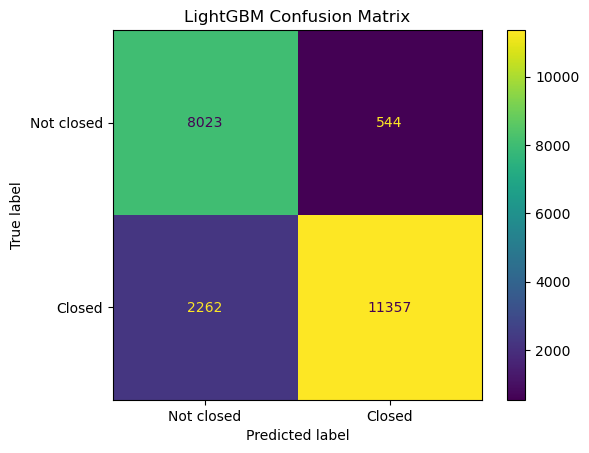

In [19]:
cm = confusion_matrix(y_val, y_pred_val)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not closed", "Closed"]
)

disp.plot(values_format="d")
plt.title("LightGBM Confusion Matrix")
plt.show()

## ROC curve

The ROC curve shows the trade-off between true positive rate and false positive rate at different probability thresholds.

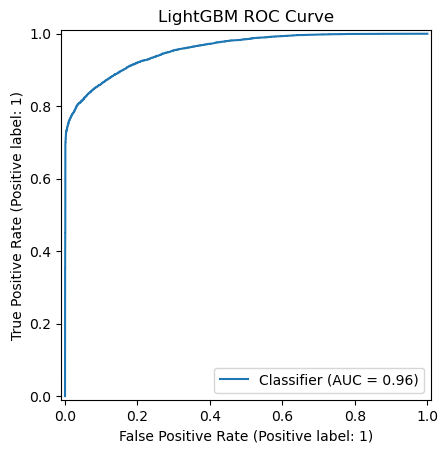

In [20]:
RocCurveDisplay.from_predictions(y_val, y_proba_val)
plt.title("LightGBM ROC Curve")
plt.show()

## Feature importance

Feature importance helps identify which variables were most useful for the LightGBM model.

This is useful for interpreting the model and comparing it with the other models in the project.

In [21]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))

,feature,importance
9,Created_Hour,3968
1,Incident Zip,3101
10,Created_DayOfWeek,2535
2,Police Precinct,1981
0,Agency,996
5,Problem_Grouped,827
7,Is_Landmark,573
4,Open Data Channel Type,378
6,Location_Grouped,358
8,Is_Taxi,137


## Plot feature importance

The plot below displays the 20 most important features according to the trained LightGBM model.

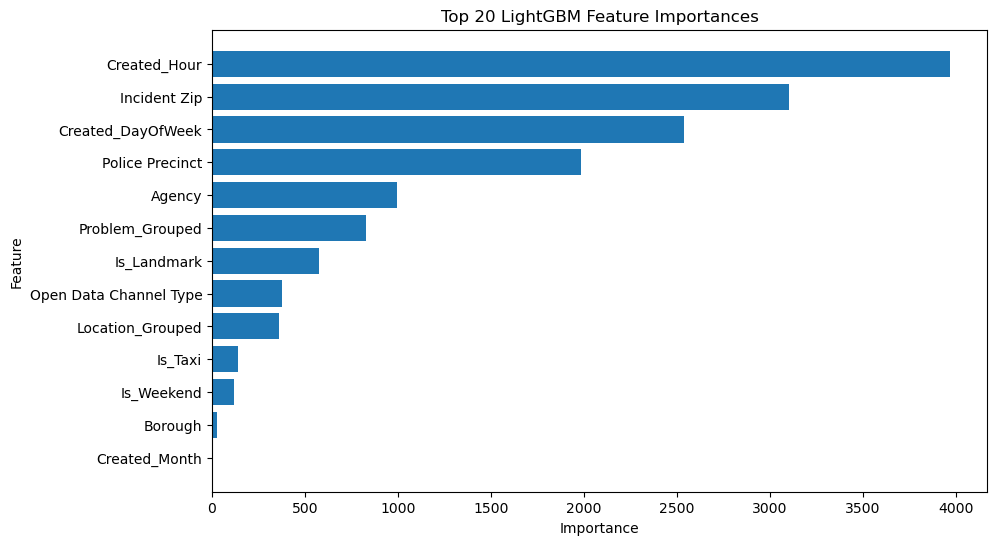

In [22]:
top_features = feature_importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 20 LightGBM Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Train the final model on the full training set

After evaluating the model on the validation set, the final model is trained using all available labeled data.

This final model is then used to predict on the official test set.

In [23]:
final_model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

final_model.fit(
    X,
    y,
    categorical_feature=categorical_cols
)

print("Final model trained on the full training set.")

Final model trained on the full training set.


## Generate predictions for the test set

The test set does not contain the target variable, so these predictions cannot be evaluated directly in this notebook.

The output contains both the predicted class and the probability of being closed within 24 hours.

In [24]:
test_predictions = final_model.predict(test)
test_probabilities = final_model.predict_proba(test)[:, 1]

print("Number of test predictions:", len(test_predictions))
print("Predicted proportion of Y = 1:", round(test_predictions.mean(), 4))

Number of test predictions: 27733
Predicted proportion of Y = 1: 0.5336


## Save the prediction file

The final CSV is saved locally in the data folder.

This file should not be pushed to GitHub unless the group specifically asks for it.

In [25]:
submission = pd.DataFrame({
    "prediction": test_predictions,
    "probability_Y_1": test_probabilities
}, index=test.index)

output_file = DATA_PATH / "submission_romain_lightgbm.csv"
submission.to_csv(output_file)

print("Submission saved to:", output_file)
display(submission.head())

Submission saved to: C:\Users\romai\Downloads\ML project data\submission_romain_lightgbm.csv


,prediction,probability_Y_1
0,0,0.275809
1,0,0.027671
2,0,0.100327
3,0,0.434438
4,0,0.023783


## Conclusion

This notebook trained a LightGBM classifier using the shared preprocessing pipeline from the project.

The model was evaluated on a stratified validation split and then retrained on the full training set to generate final predictions for the test data.